## Part 1  Problem Definition & Dataset Verification 

### 1.

In [12]:
import pandas as pd 
import math
import pandas as pd

In [13]:
df=pd.read_csv("clean_churn.csv")

In [14]:
df.shape

(7021, 20)

In [15]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7021 entries, 0 to 7020
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7021 non-null   str    
 1   SeniorCitizen     7021 non-null   int64  
 2   Partner           7021 non-null   str    
 3   Dependents        7021 non-null   str    
 4   tenure            7021 non-null   int64  
 5   PhoneService      7021 non-null   str    
 6   MultipleLines     7021 non-null   str    
 7   InternetService   7021 non-null   str    
 8   OnlineSecurity    7021 non-null   str    
 9   OnlineBackup      7021 non-null   str    
 10  DeviceProtection  7021 non-null   str    
 11  TechSupport       7021 non-null   str    
 12  StreamingTV       7021 non-null   str    
 13  StreamingMovies   7021 non-null   str    
 14  Contract          7021 non-null   str    
 15  PaperlessBilling  7021 non-null   str    
 16  PaymentMethod     7021 non-null   str    
 17  Monthl

In [16]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [17]:
df['Churn'].value_counts() 

Churn
No     5164
Yes    1857
Name: count, dtype: int64

### 2.

####  Restatement of the Problem & Dataset Verification

The core business problem is that the telecom company is experiencing customer loss (churn) to competitors, resulting in reduced revenue. The goal is to build a predictive machine learning model that identifies at-risk subscribers early so the business can take proactive retention actions. The primary target variable is Churn (indicating whether a customer left or remained).

The cleaned dataset (clean_churn.csv) has been verified and is fully intact:

- Dimensions: 7,021 rows and 20 columns.

- Data Quality: Zero missing (null) values across all features.

- Integrity: Numerical features (tenure, MonthlyCharges, TotalCharges) and categorical indicators are properly formatted and ready for training.

## Part 2  Feature & Target Preparation

## 3.

In [18]:
y = df['Churn'].map({'Yes': 1, 'No': 0})

In [19]:
X = df.drop(columns=['Churn'])

In [20]:
X

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7016,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50
7017,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90
7018,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45
7019,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60


### 4.

In [21]:
# 1. Manual Binary Mapping (0 / 1)
binary_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
for col in binary_cols:
    X[col] = X[col].map({'Yes': 1, 'No': 0})

X['gender'] = X['gender'].map({'Male': 1, 'Female': 0})

In [22]:
# 2. One-Hot Encoding for remaining multi-class categorical columns
multi_cat_cols = [
    'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
    'Contract', 'PaymentMethod'
]

X = pd.get_dummies(X, columns=multi_cat_cols, drop_first=True, dtype=int)


In [23]:
X.info()


<class 'pandas.DataFrame'>
RangeIndex: 7021 entries, 0 to 7020
Data columns (total 30 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   gender                                 7021 non-null   int64  
 1   SeniorCitizen                          7021 non-null   int64  
 2   Partner                                7021 non-null   int64  
 3   Dependents                             7021 non-null   int64  
 4   tenure                                 7021 non-null   int64  
 5   PhoneService                           7021 non-null   int64  
 6   PaperlessBilling                       7021 non-null   int64  
 7   MonthlyCharges                         7021 non-null   float64
 8   TotalCharges                           7021 non-null   float64
 9   MultipleLines_No phone service         7021 non-null   int64  
 10  MultipleLines_Yes                      7021 non-null   int64  
 11  InternetService

In [24]:
X

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,MultipleLines_No phone service,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,1,29.85,29.85,1,...,0,0,0,0,0,0,0,0,1,0
1,1,0,0,0,34,1,0,56.95,1889.50,0,...,0,0,0,0,0,1,0,0,0,1
2,1,0,0,0,2,1,1,53.85,108.15,0,...,0,0,0,0,0,0,0,0,0,1
3,1,0,0,0,45,0,0,42.30,1840.75,1,...,1,0,0,0,0,1,0,0,0,0
4,0,0,0,0,2,1,1,70.70,151.65,0,...,0,0,0,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7016,1,0,1,1,24,1,1,84.80,1990.50,0,...,1,0,1,0,1,1,0,0,0,1
7017,0,0,1,1,72,1,1,103.20,7362.90,0,...,0,0,1,0,1,1,0,1,0,0
7018,0,0,1,1,11,0,1,29.60,346.45,1,...,0,0,0,0,0,0,0,0,1,0
7019,1,1,1,0,4,1,1,74.40,306.60,0,...,0,0,0,0,0,0,0,0,0,1


#### Justification
- Binary Mapping (0/1): Used for two-value columns (gender, Partner, Dependents, PhoneService, PaperlessBilling) to convert them directly into single numeric indicator columns without unnecessarily expanding the dataset dimensions.

- One-Hot Encoding (drop_first=True): Applied to multi-class nominal features (e.g., Contract, InternetService, PaymentMethod). This prevents the model from assuming a false numeric hierarchy (which happens with label encoding) while drop_first=True prevents multicollinearity (dummy variable trap).

### 5.

In [25]:
# 1. Check if all columns are numeric
non_numeric_cols = X.select_dtypes(exclude=['number']).columns.tolist()
print("Non-numeric columns count:", len(non_numeric_cols))

Non-numeric columns count: 0


In [26]:
# 2. Check for missing values across the entire DataFrame
total_missing = X.isnull().sum().sum()
print("Total missing values:", total_missing)

Total missing values: 0


## Part 3  Train/Test Split

### 6.

In [27]:
from sklearn.model_selection import train_test_split


X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.20, random_state=42, stratify=y
)

### Why stratify=y is a sensible choice:
- Imbalanced Target Classes: The target variable Churn is imbalanced, with approximately 73.5% "No" (5,164) and 26.5% "Yes" (1,857).

- Preserving Class Distribution: Using stratify=y ensures that both the training and testing sets retain the exact same 73.5% to 26.5% ratio as the original dataset.

- Prevents Sampling Bias: A purely random split without stratification risks under-representing or completely missing the minority class ("Yes") in either the train or test set, which would lead to unreliable model evaluation.

### 7.

In [28]:
print("X_train Shape is :",X_train.shape)
print("y_train Shape is :",y_train.shape)
print("X_test Shape is :",X_test.shape)
print("y_test Shape is :",y_test.shape)

X_train Shape is : (5616, 30)
y_train Shape is : (5616,)
X_test Shape is : (1405, 30)
y_test Shape is : (1405,)


- X_train: (5616, 30) — 5,616 samples with 30 features

- y_train: (5616,) — 5,616 target labels

- X_test: (1405, 30) — 1,405 samples with 30 features

-  y_test: (1405,) — 1,405 target labels

## Part 4  Baseline Decision Tree 

### 8.

In [29]:
from sklearn.tree import DecisionTreeClassifier

In [30]:
model=DecisionTreeClassifier(random_state=42)

In [31]:
model.fit(X_train,y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [32]:
# Generate predictions on both training and test sets
y_train_pred =model.predict(X_train)
y_test_pred = model.predict(X_test)

### 9.

In [33]:
model.get_depth()

25

**Tree Depth:**
The tree grew to a depth of **25**.

**Does that surprise you?**
**No, this is not surprising.**

* **Default Behavior:** By default, DecisionTreeClassifier sets max_depth=None. This means the algorithm continues splitting nodes until every leaf is completely pure (100% accurate on the training set) or contains fewer samples than min_samples_split.
* **Dataset Complexity:** Because the dataset contains over 5,600 training samples and 30 features, an unconstrained tree naturally grows very deep to memorize individual data points and noise, leading to **overfitting**.

## Part 5  Model Evaluation 

In [34]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [35]:
results = {
    "Metric": ["Accuracy", "Precision", "Recall", "F1-Score"],
    "Score": [
        accuracy_score(y_test, y_test_pred),
        precision_score(y_test, y_test_pred, average="weighted"),
        recall_score(y_test, y_test_pred, average="weighted"),
        f1_score(y_test, y_test_pred, average="weighted"),
    ],
}

In [36]:
df_results = pd.DataFrame(results)
df_results

,Metric,Score
0,Accuracy,0.727402
1,Precision,0.729528
2,Recall,0.727402
3,F1-Score,0.728435


In [37]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

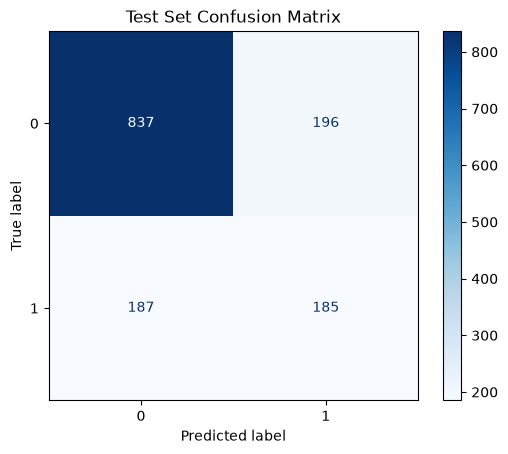

In [38]:
cm = confusion_matrix(y_test, y_test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title("Test Set Confusion Matrix")
plt.show()

In [39]:
correctly_caught = cm[1, 1]  # True Positives (Actual 1, Predicted 1)
missed = cm[1, 0]  # False Negatives (Actual 1, Predicted 0)

In [40]:
print(f"Correctly caught churners: {correctly_caught}")
print(f"Missed churners: {missed}")

Correctly caught churners: 185
Missed churners: 187


### 12.

**Most Trusted Metric(s):**

* **Recall (Most Critical):** High recall minimizes False Negatives, ensuring the business identifies as many at-risk churners as possible for proactive retention.


* **F1-Score:** Harmonic mean of precision and recall that provides a reliable overall performance measure on imbalanced data.


* **Why not Accuracy:** With a ~73.5% non-churn majority, a naive baseline predicting "No Churn" achieves 73.5% accuracy while completely failing to catch any churners.

## Part 6  Overfitting Investigation 

### 13.

In [41]:
train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)

print(f"Training Accuracy: {train_acc:.4f}")
print(f"Test Accuracy:     {test_acc:.4f}")
print(f"Accuracy Gap:      {train_acc - test_acc:.4f}")

Training Accuracy: 0.9977
Test Accuracy:     0.7274
Accuracy Gap:      0.2703


**Overfitting Analysis:**

- Comparison & Gap: Yes, there is a large gap of 27.03% between training accuracy (99.77%) and test accuracy (72.74%).

- What it suggests: This substantial drop indicates severe overfitting (high variance). The unconstrained decision tree grew too deep (depth 25), effectively memorizing training noise and outliers rather than learning generalized patterns.

### 14.

In [42]:
# Define max_depth values to evaluate
depths = [2, 3, 4, 5, 6, 8, 10, None]

results = []

for d in depths:
    # Train Decision Tree
    dt = DecisionTreeClassifier(max_depth=d, random_state=42)
    dt.fit(X_train, y_train)

    # Predictions
    y_tr_pred = dt.predict(X_train)
    y_te_pred = dt.predict(X_test)

    # Accuracies
    tr_acc = accuracy_score(y_train, y_tr_pred)
    te_acc = accuracy_score(y_test, y_te_pred)

    results.append(
        {
            "max_depth": "None (Unrestricted)" if d is None else str(d),
            "Train Accuracy": round(tr_acc, 4),
            "Test Accuracy": round(te_acc, 4),
            "Accuracy Gap": round(tr_acc - te_acc, 4),
        }
    )

# Results table display karein
results_df = pd.DataFrame(results)
results_df

,max_depth,Train Accuracy,Test Accuracy,Accuracy Gap
0,2,0.7922,0.7836,0.0086
1,3,0.7922,0.7836,0.0086
2,4,0.7952,0.7843,0.0109
3,5,0.8018,0.7872,0.0146
4,6,0.8082,0.7851,0.0232
5,8,0.8355,0.7801,0.0554
6,10,0.8695,0.7701,0.0994
7,None (Unrestricted),0.9977,0.7274,0.2703


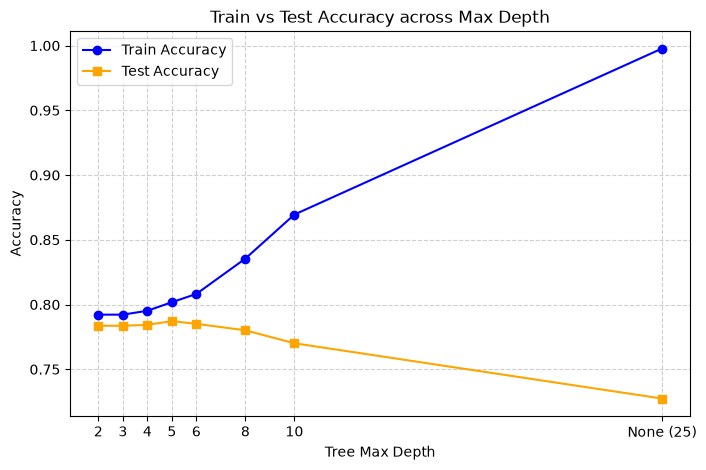

In [43]:
import matplotlib.pyplot as plt

# Numeric depth values for plotting (using 25 for unrestricted baseline)
plot_depths = [2, 3, 4, 5, 6, 8, 10, 25]

plt.figure(figsize=(8, 5))
plt.plot(
    plot_depths,
    results_df["Train Accuracy"],
    marker="o",
    label="Train Accuracy",
    color="blue",
)
plt.plot(
    plot_depths,
    results_df["Test Accuracy"],
    marker="s",
    label="Test Accuracy",
    color="orange",
)

plt.xlabel("Tree Max Depth")
plt.ylabel("Accuracy")
plt.title("Train vs Test Accuracy across Max Depth")
plt.xticks(plot_depths, labels=["2", "3", "4", "5", "6", "8", "10", "None (25)"])
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.show()

**Overfitting Point:** The model starts to overfit at max_depth = 5 to 6.

**Explanation from the Chart:**

- Test accuracy peaks at max_depth = 5 (0.7872).

- Beyond depth 5, Train Accuracy continues to rise steeply (eventually reaching 0.9977), while Test Accuracy declines consistently (falling to 0.7274).

- This widening divergence (growing accuracy gap) on the chart clearly demonstrates that deeper trees are fitting training noise rather than generalizing.

## Part 7  Model Selection, Feature Importance & Interpretation 

### 16.

**Selection and Justification of Best max_depth**
- Selected Depth: max_depth = 5

**Justification:** max_depth = 5 yields the highest test accuracy (78.72%) while maintaining a minimal generalization gap of only 1.46% between training and test sets. Depths beyond 5 increase training accuracy purely by memorizing training noise, which causes test performance to degrade.

### 17.

In [44]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from sklearn.tree import DecisionTreeClassifier

# Retrain model with best depth
best_tree = DecisionTreeClassifier(max_depth=5, random_state=42)
best_tree.fit(X_train, y_train)

y_test_pred_best = best_tree.predict(X_test)

metrics_best = {
    "Metric": ["Accuracy", "Precision", "Recall", "F1-Score"],
    "Score": [
        accuracy_score(y_test, y_test_pred_best),
        precision_score(y_test, y_test_pred_best, average="weighted"),
        recall_score(y_test, y_test_pred_best, average="weighted"),
        f1_score(y_test, y_test_pred_best, average="weighted"),
    ],
}

pd.DataFrame(metrics_best)

,Metric,Score
0,Accuracy,0.787189
1,Precision,0.771912
2,Recall,0.787189
3,F1-Score,0.770794


### 18.

In [45]:
# Retrain model using entropy criterion
entropy_tree = DecisionTreeClassifier(
    criterion="entropy", max_depth=5, random_state=42
)
entropy_tree.fit(X_train, y_train)

y_test_pred_entropy = entropy_tree.predict(X_test)

metrics_entropy = {
    "Metric": ["Accuracy", "Precision", "Recall", "F1-Score"],
    "Score": [
        accuracy_score(y_test, y_test_pred_entropy),
        precision_score(y_test, y_test_pred_entropy, average="weighted"),
        recall_score(y_test, y_test_pred_entropy, average="weighted"),
        f1_score(y_test, y_test_pred_entropy, average="weighted"),
    ],
}

pd.DataFrame(metrics_entropy)

,Metric,Score
0,Accuracy,0.787900
1,Precision,0.776110
2,Recall,0.787900
3,F1-Score,0.778813


### 19.

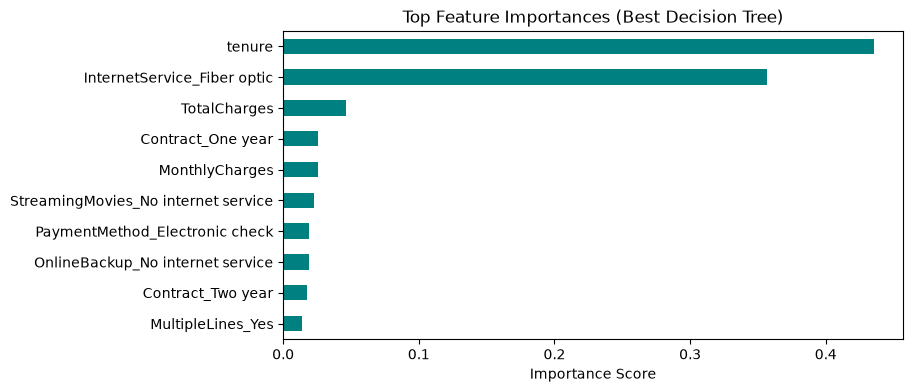

Top 5 Features:
 tenure                         0.435296
InternetService_Fiber optic    0.356418
TotalCharges                   0.046020
Contract_One year              0.025760
MonthlyCharges                 0.025629
dtype: float64


In [46]:


# Extract feature importances
feat_imp = (
    pd.Series(best_tree.feature_importances_, index=X_train.columns)
    .sort_values(ascending=False)
    .head(10)
)

# Plot top 10 features
plt.figure(figsize=(8, 4))
feat_imp.sort_values().plot(kind="barh", color="teal")
plt.title("Top Feature Importances (Best Decision Tree)")
plt.xlabel("Importance Score")
plt.show()

print("Top 5 Features:\n", feat_imp.head(5))

### 20.

 **Connection to Lab 2 EDA FindingsAgreement with EDA:**
 
 Yes, the model's top features directly confirm and agree with the core findings from Lab 2. 
 
 **Explanation:**
 **tenure (Importance: ~0.435):** 
 
 In Lab 2, tenure was identified as a primary churn indicator, showing that churn is heavily concentrated among newer customers (median tenure of 10 months vs. 38 months for retained customers).  
 
 **InternetService_Fiber optic (Importance: ~0.356):** In Lab 2, Fiber optic users had the highest churn rate of any category (~41.9%), driven by high monthly costs and service sensitivity. 
 
 **Pricing & Contract Features (TotalCharges, MonthlyCharges, Contract_One year):**
 
 Matches Lab 2's findings that short-term commitments (Month-to-month) and higher monthly bills (~$79.65 median for churners) significantly drive customer attrition.  

## Part 8 — Conclusion & Next Steps 

### 21. Conclusion



- **Final Model:** The Decision Tree Classifier with max_depth = 5 using the Gini/Entropy criterion was selected as the final model.

- **Performance:** It achieved a test accuracy of ~78.7% with an F1-score of ~0.77, significantly reducing the baseline model's severe overfitting gap (from 27% down to ~1.5%).

- **Limitations:** As a single, pruned decision tree, it struggles to capture complex non-linear feature interactions and remains vulnerable to the underlying class imbalance, leading to missed churners (lower recall on the positive class).

### 23.

In [47]:
# Standard Play Badminton dataset
data = {
    'Outlook': ['Sunny', 'Sunny', 'Overcast', 'Rain', 'Rain', 'Rain', 'Overcast', 'Sunny', 'Sunny', 'Rain', 'Sunny', 'Overcast', 'Overcast', 'Rain'],
    'Temperature': ['Hot', 'Hot', 'Hot', 'Mild', 'Cool', 'Cool', 'Cool', 'Mild', 'Cool', 'Mild', 'Mild', 'Mild', 'Hot', 'Mild'],
    'Humidity': ['High', 'High', 'High', 'High', 'Normal', 'Normal', 'Normal', 'High', 'Normal', 'Normal', 'Normal', 'High', 'Normal', 'High'],
    'Wind': ['Weak', 'Strong', 'Weak', 'Weak', 'Weak', 'Strong', 'Strong', 'Weak', 'Weak', 'Weak', 'Strong', 'Strong', 'Weak', 'Strong'],
    'Play': ['No', 'No', 'Yes', 'Yes', 'Yes', 'No', 'Yes', 'No', 'Yes', 'Yes', 'Yes', 'Yes', 'Yes', 'No']
}
df = pd.DataFrame(data)

In [48]:
def entropy(target_col):
    values, counts = target_col.value_counts(), target_col.value_counts()
    total = len(target_col)
    ent = 0.0
    for count in counts:
        p = count / total
        if p > 0:
            ent -= p * math.log2(p)
    return ent

In [49]:
def info_gain(df, attribute, target_name="Play"):
    total_entropy = entropy(df[target_name])
    vals, counts = df[attribute].value_counts().index, df[attribute].value_counts()
    total_len = len(df)
    
    subset_entropy = 0.0
    for val, count in zip(vals, counts):
        sub_df = df[df[attribute] == val]
        subset_entropy += (count / total_len) * entropy(sub_df[target_name])
        
    return total_entropy - subset_entropy

In [50]:
def id3(df, features, target_name="Play", depth=0):
    # Base Case 1: Pure leaf
    if len(df[target_name].unique()) == 1:
        return df[target_name].iloc[0]
    
    # Base Case 2: No more features left
    if len(features) == 0:
        return df[target_name].mode()[0]
    
    print(f"\n--- Split at Depth {depth} ---")
    gains = {}
    for feat in features:
        gains[feat] = info_gain(df, feat, target_name)
        print(f"Gain({feat}) = {gains[feat]:.4f}")
        
    best_feat = max(gains, key=gains.get)
    print(f"-> Best Attribute to split: {best_feat}")
    
    tree = {best_feat: {}}
    remaining_features = [f for f in features if f != best_feat]
    
    for val in df[best_feat].unique():
        sub_df = df[df[best_feat] == val]
        subtree = id3(sub_df, remaining_features, target_name, depth + 1)
        tree[best_feat][val] = subtree
        
    return tree

In [51]:


# Run ID3
features = [col for col in df.columns if col != 'Play']
decision_tree = id3(df, features, target_name='Play')

print("\nFinal Decision Tree Structure:")
print(decision_tree)


--- Split at Depth 0 ---
Gain(Outlook) = 0.2467
Gain(Temperature) = 0.0292
Gain(Humidity) = 0.1518
Gain(Wind) = 0.0481
-> Best Attribute to split: Outlook

--- Split at Depth 1 ---
Gain(Temperature) = 0.5710
Gain(Humidity) = 0.9710
Gain(Wind) = 0.0200
-> Best Attribute to split: Humidity

--- Split at Depth 1 ---
Gain(Temperature) = 0.0200
Gain(Humidity) = 0.0200
Gain(Wind) = 0.9710
-> Best Attribute to split: Wind

Final Decision Tree Structure:
{'Outlook': {'Sunny': {'Humidity': {'High': 'No', 'Normal': 'Yes'}}, 'Overcast': 'Yes', 'Rain': {'Wind': {'Weak': 'Yes', 'Strong': 'No'}}}}
